In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, entropy
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone  # Added missing import
import shap
from tqdm import tqdm
from sklearn.metrics import r2_score  # Added for completeness

class ESHAPExplainer:
    def __init__(self, model, X_train, y_train, beta=5.0, random_state=None):
        """
        Initialize E-SHAP explainer
        
        Args:
            model: Trained tree ensemble model (RandomForest, XGBoost, etc.)
            X_train: Training features
            y_train: Training labels
            beta: Temperature parameter for softmax weighting
            random_state: Random seed
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.beta = beta
        self.random_state = random_state
        self.weights_ = self._compute_tree_weights()
        self.full_explainer = shap.TreeExplainer(model)
        
    def _compute_tree_weights(self):
        """Compute tree weights based on performance"""
        if hasattr(self.model, 'estimators_'):
            scores = []
            for tree in self.model.estimators_:
                pred = tree.predict(self.X_train)
                if len(pred.shape) > 1 and pred.shape[1] > 1:  # Classification
                    score = accuracy_score(self.y_train, np.argmax(pred, axis=1))
                else:  # Regression
                    score = r2_score(self.y_train, pred)
                scores.append(score)
            
            # Softmax weighting with temperature control
            max_score = np.max(scores)
            exp_vals = np.exp(self.beta * (np.array(scores) - max_score))
            return exp_vals / np.sum(exp_vals)
        else:
            # Single tree model
            return np.array([1.0])
    
    def explain(self, x, n_samples=500, alpha=1.0):
        """
        Compute E-SHAP values with uncertainty quantification
        
        Args:
            x: Input instance to explain
            n_samples: Number of hypothesis samples
            alpha: Dirichlet concentration parameter
            
        Returns:
            Dictionary with SHAP distributions and uncertainty metrics
        """
        np.random.seed(self.random_state)
        n_trees = len(self.model.estimators_)
        n_features = x.shape[1]
        phi_dist = np.zeros((n_samples, n_features))
        
        for s in tqdm(range(n_samples), desc="Sampling hypothesis space"):
            # Dirichlet-weighted tree sampling
            dirichlet_weights = np.random.dirichlet(alpha * self.weights_)
            tree_indices = np.random.choice(
                n_trees, 
                size=n_trees, 
                p=dirichlet_weights
            )
            
            # Create sub-ensemble with sampled trees
            sub_ensemble = [self.model.estimators_[i] for i in tree_indices]
            temp_model = clone(self.model)
            temp_model.estimators_ = sub_ensemble
            
            # Compute SHAP values for sub-ensemble
            explainer = shap.TreeExplainer(temp_model)
            phi = explainer.shap_values(x)
            # Handle multi-class output
            phi_dist[s] = phi[0] if isinstance(phi, list) else phi
        
        # Compute uncertainty metrics
        results = {
            "mean": np.mean(phi_dist, axis=0),
            "std": np.std(phi_dist, axis=0),
            "ci_95": np.percentile(phi_dist, [2.5, 97.5], axis=0),
            "entropy": self._compute_entropy(phi_dist),
            "sign_stability": self._compute_sign_stability(phi_dist),
            "samples": phi_dist
        }
        return results
    
    def _compute_entropy(self, phi_dist):
        """Compute explanation entropy for each feature"""
        entropies = []
        for i in range(phi_dist.shape[1]):
            hist, bin_edges = np.histogram(phi_dist[:, i], bins=10, density=True)
            bin_probs = hist * np.diff(bin_edges)
            entropies.append(entropy(bin_probs))
        return np.array(entropies)
    
    def _compute_sign_stability(self, phi_dist):
        """Compute sign stability for each feature"""
        mean_sign = np.sign(np.mean(phi_dist, axis=0))
        stability = np.mean(np.sign(phi_dist) == mean_sign[np.newaxis, :], axis=0)
        return stability
    
    def plot_uncertainty_bars(self, result, feature_names, title="E-SHAP Values with Epistemic Uncertainty"):
        """
        Plot SHAP values with uncertainty bars
        
        Args:
            result: E-SHAP result dictionary
            feature_names: List of feature names
            title: Plot title
        """
        plt.figure(figsize=(12, 8))
        order = np.argsort(result['mean'])
        y_pos = np.arange(len(feature_names))
        
        plt.barh(
            y_pos, 
            result['mean'][order],
            xerr=2*result['std'][order],
            capsize=5,
            alpha=0.7,
            color='skyblue',
            ecolor='darkred'
        )
        
        plt.yticks(y_pos, [feature_names[i] for i in order])
        plt.xlabel('SHAP Value')
        plt.title(title)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_distribution(self, result, feature_names, feature_idx, title="SHAP Distribution"):
        """
        Plot kernel density estimate of SHAP distribution for a feature
        
        Args:
            result: E-SHAP result dictionary
            feature_names: List of feature names
            feature_idx: Index of feature to plot
            title: Plot title
        """
        plt.figure(figsize=(10, 6))
        samples = result['samples'][:, feature_idx]
        
        # Kernel density estimation
        kde = gaussian_kde(samples)
        x = np.linspace(min(samples), max(samples), 1000)
        plt.plot(x, kde(x), lw=2, color='navy')
        
        # Uncertainty metrics
        plt.axvline(result['mean'][feature_idx], color='red', linestyle='--', label='Mean')
        plt.axvspan(
            result['ci_95'][0][feature_idx],
            result['ci_95'][1][feature_idx],
            alpha=0.2, 
            color='skyblue',
            label='95% CI'
        )
        
        plt.xlabel(f'SHAP Value for {feature_names[feature_idx]}')
        plt.ylabel('Density')
        plt.title(f"{title}\n"
                f"Std: {result['std'][feature_idx]:.4f} | "
                f"Entropy: {result['entropy'][feature_idx]:.4f} | "
                f"Sign Stability: {result['sign_stability'][feature_idx]:.2%}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_heatmap(self, result, feature_names, title="SHAP Uncertainty Heatmap"):
        """
        Plot heatmap of SHAP uncertainty metrics
        
        Args:
            result: E-SHAP result dictionary
            feature_names: List of feature names
            title: Plot title
        """
        metrics = np.vstack([
            result['mean'],
            result['std'],
            result['entropy'],
            result['sign_stability']
        ])
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(
            metrics,
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            center=0,
            xticklabels=feature_names,
            yticklabels=['Mean', 'Std Dev', 'Entropy', 'Sign Stability']
        )
        plt.title(title)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_comparison(self, result, feature_names, title="Uncertainty Comparison"):
        """
        Plot comparison of different uncertainty metrics
        
        Args:
            result: E-SHAP result dictionary
            feature_names: List of feature names
            title: Plot title
        """
        fig, axes = plt.subplots(3, 1, figsize=(12, 15))
        
        # Sort by SHAP magnitude
        order = np.argsort(result['mean'])
        
        # Standard Deviation
        axes[0].barh(
            [feature_names[i] for i in order],
            result['std'][order],
            color='teal',
            alpha=0.7
        )
        axes[0].set_title('Standard Deviation')
        axes[0].set_xlabel('Uncertainty')
        
        # Entropy
        axes[1].barh(
            [feature_names[i] for i in order],
            result['entropy'][order],
            color='purple',
            alpha=0.7
        )
        axes[1].set_title('Explanation Entropy')
        axes[1].set_xlabel('Uncertainty')
        
        # Sign Stability
        axes[2].barh(
            [feature_names[i] for i in order],
            result['sign_stability'][order],
            color='orange',
            alpha=0.7
        )
        axes[2].set_title('Sign Stability')
        axes[2].set_xlabel('Probability')
        axes[2].set_xlim(0, 1)
        
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

# # Example Usage
# if __name__ == "__main__":
#     from sklearn.datasets import load_diabetes
#     from sklearn.metrics import r2_score, accuracy_score
    
#     # Load dataset and train model
#     data = load_diabetes()
#     X, y = data.data, data.target
#     feature_names = data.feature_names
    
#     model = RandomForestRegressor(n_estimators=100, random_state=42)
#     model.fit(X, y)
    
#     # Initialize E-SHAP explainer
#     eshap = ESHAPExplainer(model, X, y, beta=5.0, random_state=42)
    
#     # Explain an instance
#     instance = X[0:1]  # First sample
#     result = eshap.explain(instance, n_samples=500)
    
#     # Visualizations
#     eshap.plot_uncertainty_bars(result, feature_names, "Diabetes Progression Feature Importance")
#     eshap.plot_uncertainty_distribution(result, feature_names, 2, "SHAP Distribution for BMI")
#     eshap.plot_uncertainty_heatmap(result, feature_names, "Diabetes SHAP Uncertainty Metrics")
#     eshap.plot_uncertainty_comparison(result, feature_names, "Uncertainty Comparison for Diabetes Features")

In [16]:
from sklearn.datasets import load_diabetes
import pandas as pd
df = pd.read_csv("pcos_dataset.csv")

df.head()


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [17]:
# Load dataset and train model

X = df.drop("PCOS_Diagnosis", axis = 1)
y = df["PCOS_Diagnosis"]
feature_names = X.columns
print(feature_names)

Index(['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)',
       'Antral_Follicle_Count'],
      dtype='object')


/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but De


Feature Impact Summary with Uncertainty Quantification:
- Age: -0.0000 ± 0.0000 (95% CI: [-0.0001, 0.0000], Sign Stability: 14.00%)
- BMI: 0.0811 ± 0.0038 (95% CI: [0.0724, 0.0880], Sign Stability: 100.00%)
- Menstrual_Irregularity: -0.3492 ± 0.0096 (95% CI: [-0.3701, -0.3309], Sign Stability: 100.00%)
- Testosterone_Level(ng/dL): 0.0409 ± 0.0029 (95% CI: [0.0364, 0.0468], Sign Stability: 100.00%)
- Antral_Follicle_Count: 0.0281 ± 0.0030 (95% CI: [0.0233, 0.0335], Sign Stability: 100.00%)



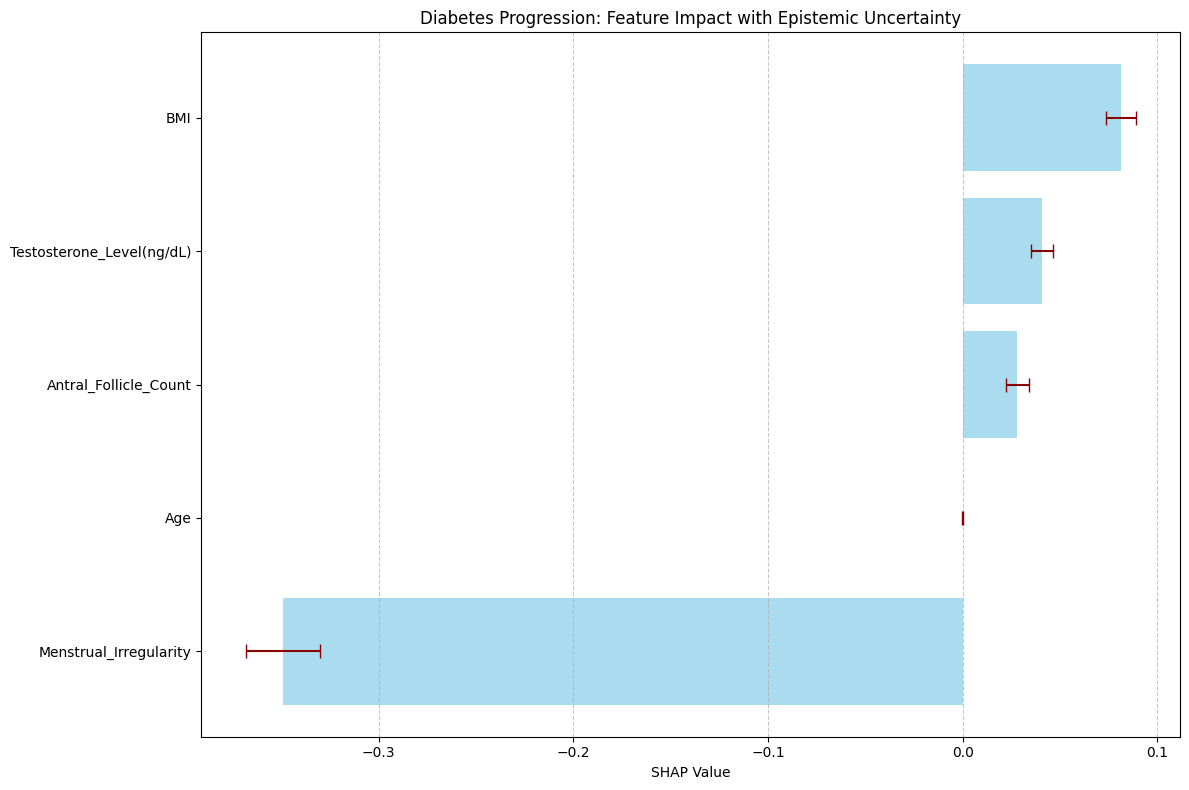

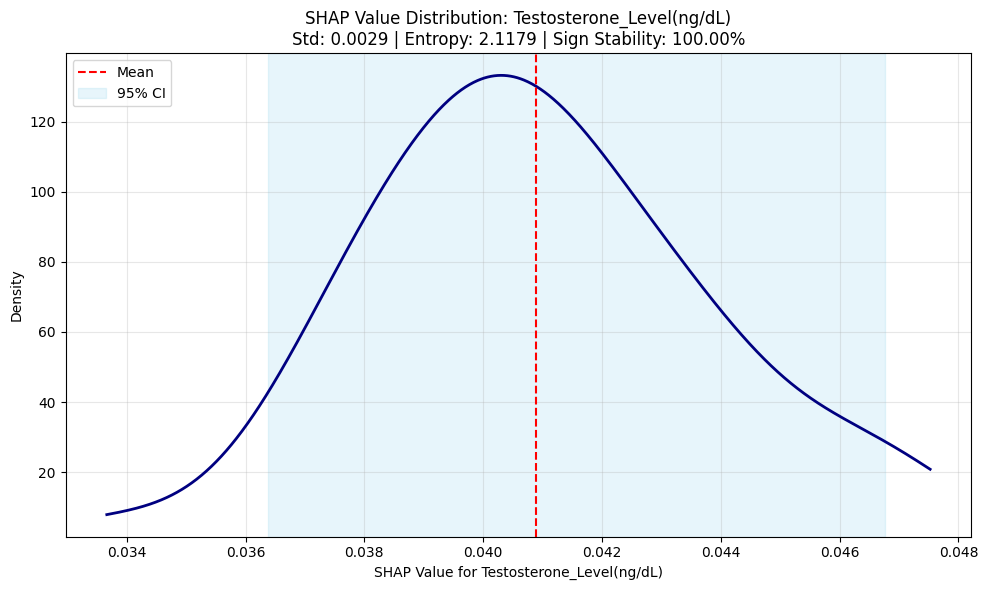

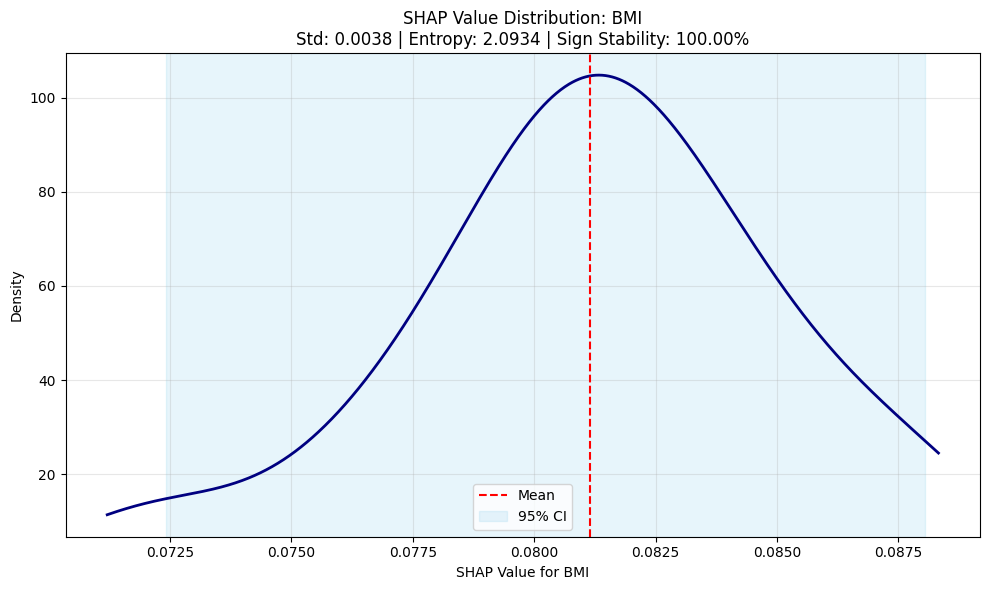

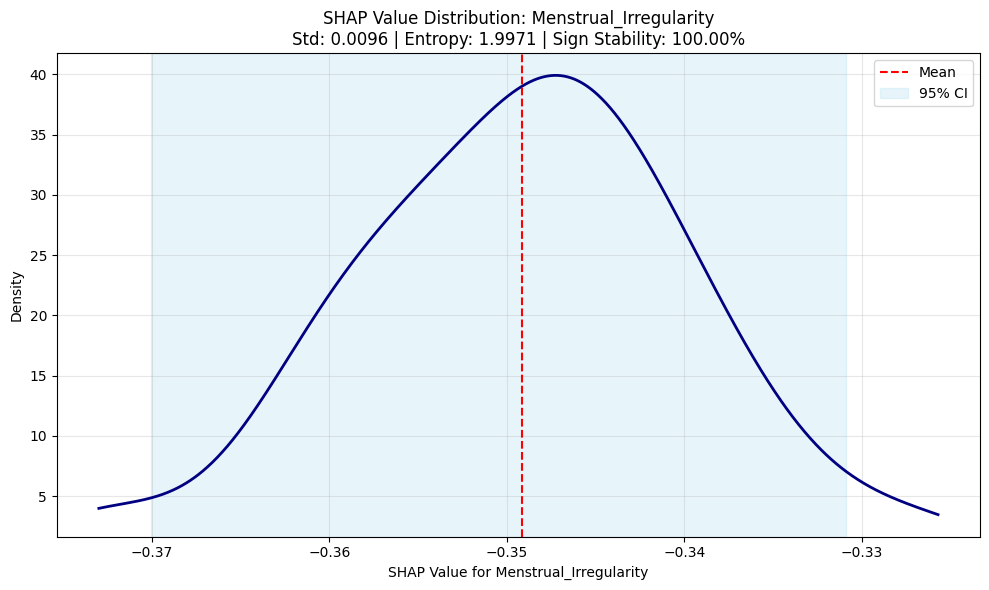

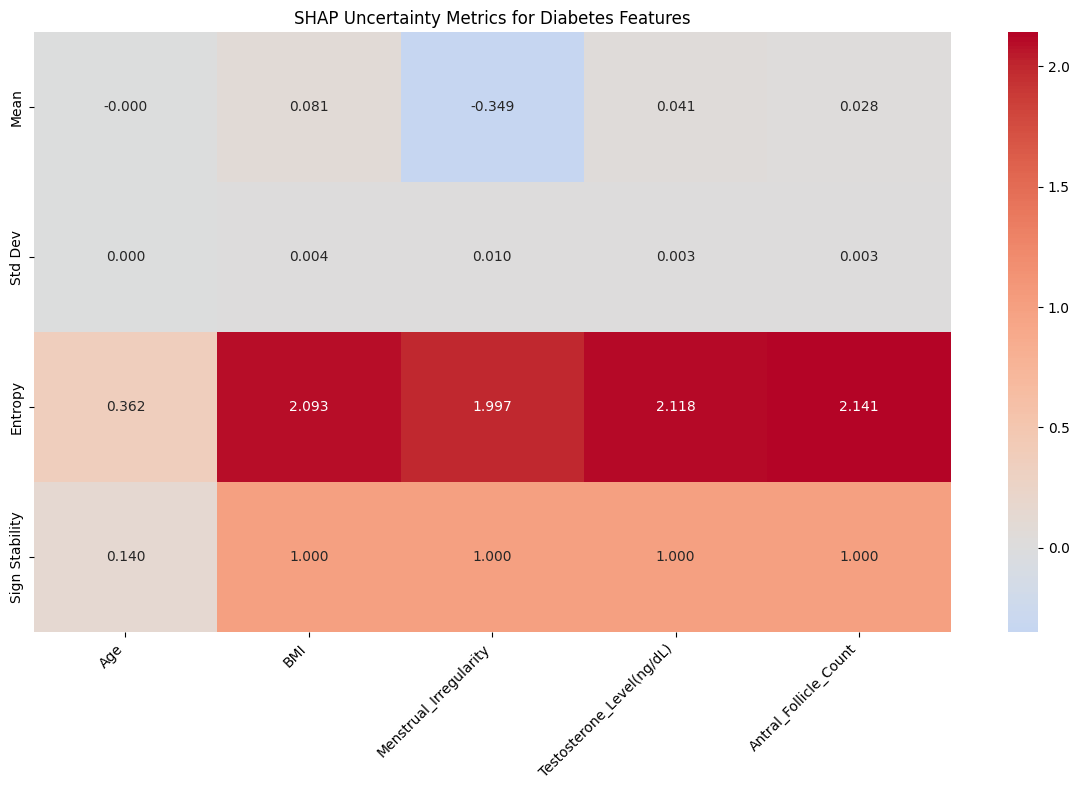

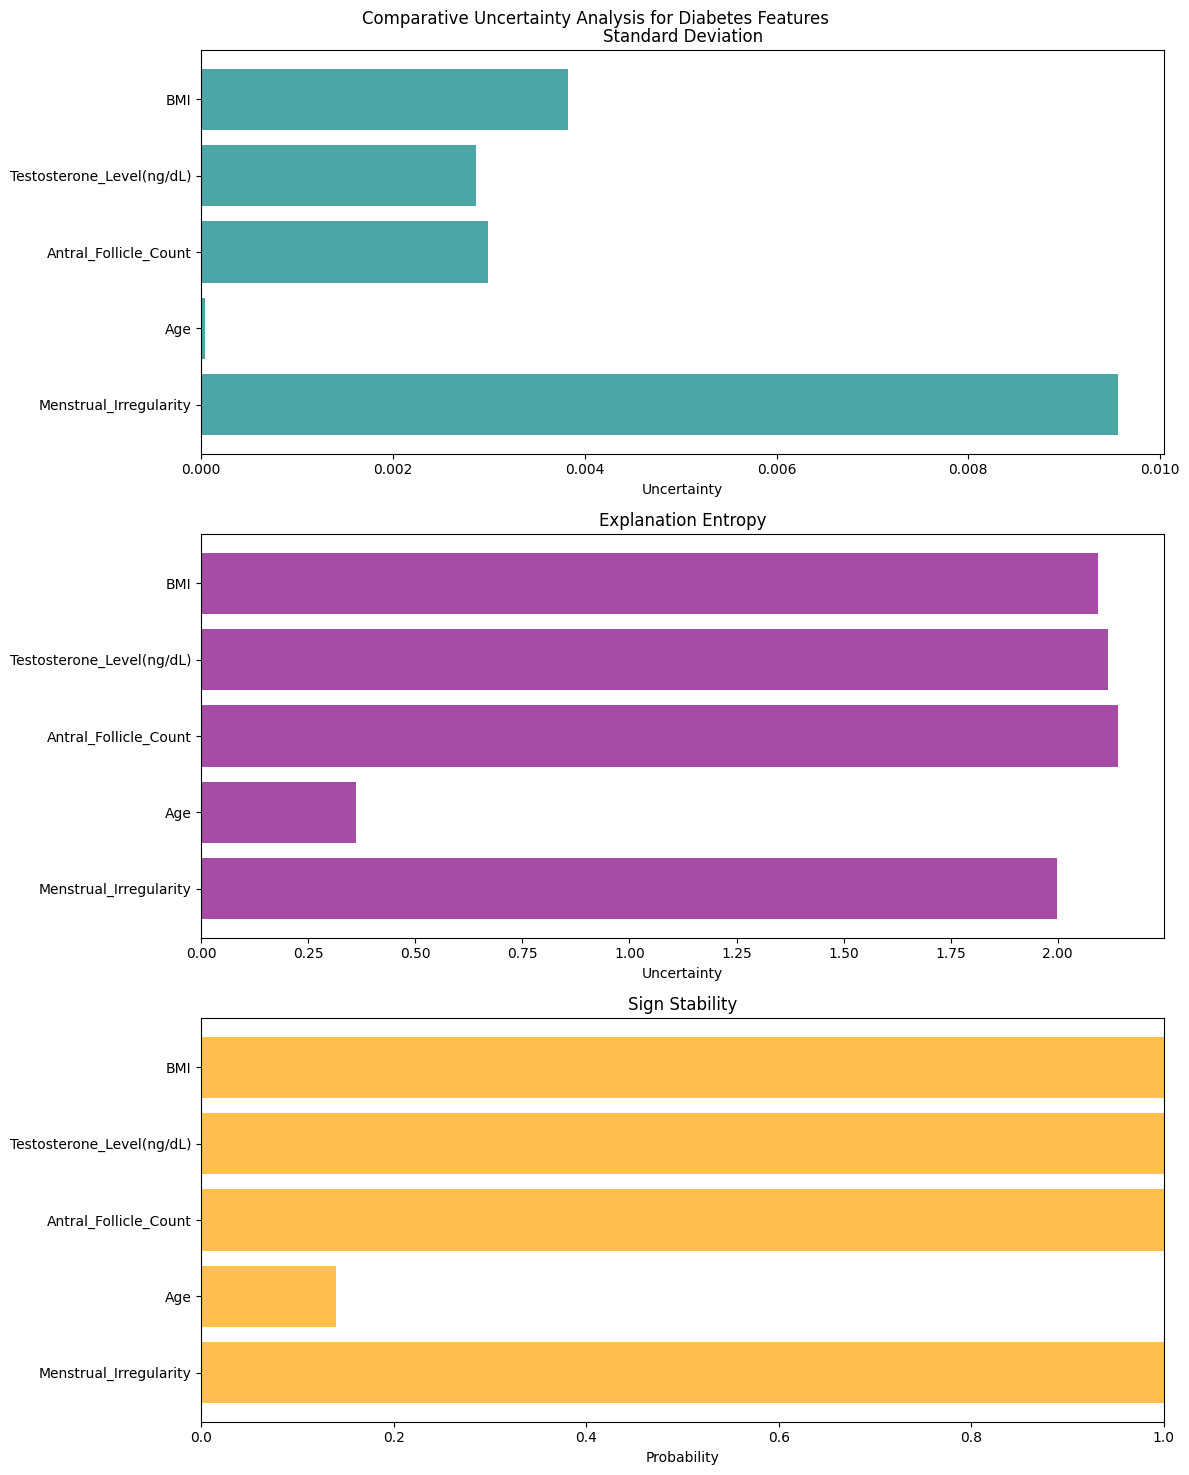

In [23]:

model = RandomForestRegressor(n_estimators=10000, random_state=42)
model.fit(X, y)

# Initialize E-SHAP explainer
eshap = ESHAPExplainer(model, X, y, beta=5.0, random_state=42)

# Explain an instance
instance = X[42:43]  # Select an interesting instance
result = eshap.explain(instance, n_samples=50)

print("\n" + "="*80)
print("Feature Impact Summary with Uncertainty Quantification:")
for i, name in enumerate(feature_names):
    print(f"- {name}: {result['mean'][i]:.4f} ± {result['std'][i]:.4f} "
            f"(95% CI: [{result['ci_95'][0][i]:.4f}, {result['ci_95'][1][i]:.4f}], "
            f"Sign Stability: {result['sign_stability'][i]:.2%})")
print("="*80 + "\n")

# Visualizations
eshap.plot_uncertainty_bars(result, feature_names, 
                            "Diabetes Progression: Feature Impact with Epistemic Uncertainty")

# Plot distributions for top 3 features
top_features = np.argsort(np.abs(result['mean']))[-3:]
for idx in top_features:
    eshap.plot_uncertainty_distribution(result, feature_names, idx, 
                                        f"SHAP Value Distribution: {feature_names[idx]}")

eshap.plot_uncertainty_heatmap(result, feature_names, 
                                "SHAP Uncertainty Metrics for Diabetes Features")

eshap.plot_uncertainty_comparison(result, feature_names, 
                                "Comparative Uncertainty Analysis for Diabetes Features")

In [24]:
import shap

In [25]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

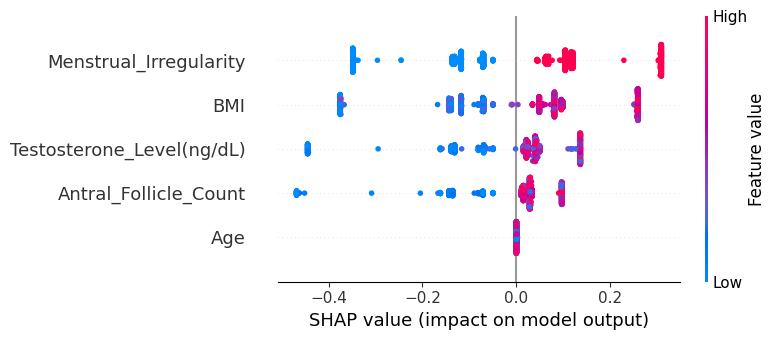

In [26]:
shap.summary_plot(shap_values, X)

In [28]:
shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X.iloc[:20, :])

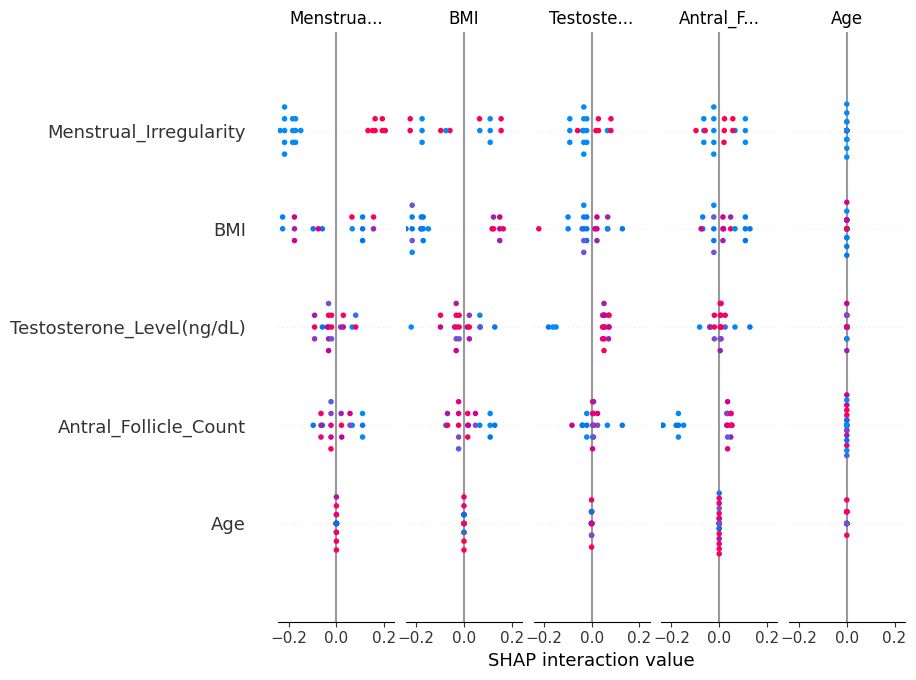

In [30]:
shap.summary_plot(shap_interaction_values, X.iloc[:20, :])

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count
Age,1.000000,-0.049455,0.032300,-0.050129,0.017841
BMI,-0.049455,1.000000,0.031189,0.003811,0.030724
Menstrual_Irregularity,0.032300,0.031189,1.000000,0.042694,0.035851
Testosterone_Level(ng/dL),-0.050129,0.003811,0.042694,1.000000,0.011976
Antral_Follicle_Count,0.017841,0.030724,0.035851,0.011976,1.000000
